In [14]:
import os

# Retrieve the absolute path of the current working directory
# In a Jupyter environment, this points to the folder containing the .ipynb file
base_path = os.getcwd()

# Define and create a 'figures' directory to store analysis plots
# 'exist_ok=True' ensures no error is thrown if the directory already exists
figures_path = os.path.join(base_path, "figures")
os.makedirs(figures_path, exist_ok=True)

print(f"Current project base path: {base_path}")
print(f"Figures directory initialized at: {figures_path}")

Current project base path: /Users/qgroup/Desktop/final_draft
Figures directory initialized at: /Users/qgroup/Desktop/final_draft/figures


In [40]:
import pandas as pd
import numpy as np
import ast
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# Utility Functions
# ==========================================
def safe_to_list(x):
    """
    Safely converts string-formatted lists into Python list objects.
    Returns an empty list if conversion fails or if input is invalid.
    """
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return []

def main():
    # ==========================================
    # Configuration
    # (Defined inside main to avoid scope errors)
    # ==========================================
    base_path = "/Users/qgroup/Downloads/draft" # Define your base_path here
    
    # Recommended to use the file updated with 'Semantic' naming
    input_file = f"{base_path}/short_novel_with_surprisal_coherence_semantic.csv"
    
    # Output paths
    output_csv = f"{base_path}/short_novel_correlations.csv"
    output_plot = f"{base_path}/signal_correlations_dist.png"

    # ==========================================
    # Execution Logic
    # ==========================================
    print(f"Loading data from: {input_file}")
    
    # Check file existence and handle Fallback
    if not os.path.exists(input_file):
        # Fallback to 'topic' version if 'semantic' version is missing
        fallback = input_file.replace("semantic", "topic")
        if os.path.exists(fallback):
            print(f"Warning: 'semantic' file not found. Loading 'topic' file: {fallback}")
            input_file = fallback
        else:
            print(f"Error: Input file not found at {input_file}")
            return

    df = pd.read_csv(input_file)
    
    # Automatic column detection (semantic vs topic)
    col_map = {
        "surprisal": "surprisal_vector", # Default mapping
        "coherence": "coherence_vector",
        "semantic": "semantic_shift_vector" 
    }
    
    # Update mapping based on actual column names in the DataFrame
    for col in df.columns:
        if "surprisal" in col and ("vector" in col or "list" in col):
            col_map["surprisal"] = col
        if "coherence" in col and ("vector" in col or "list" in col):
            col_map["coherence"] = col
        if ("semantic_shift" in col or "topic_shift" in col) and ("vector" in col or "list" in col):
            col_map["semantic"] = col

    print(f"Using columns: {col_map}")

    # Data parsing
    # Check for column existence to prevent errors
    if col_map["surprisal"] not in df.columns:
         print(f"Error: Surprisal column '{col_map['surprisal']}' not found.")
         return
         
    df["s_vec"] = df[col_map["surprisal"]].apply(safe_to_list)
    df["c_vec"] = df[col_map["coherence"]].apply(safe_to_list)
    df["m_vec"] = df[col_map["semantic"]].apply(safe_to_list)

    # Lists to store correlation coefficients
    corr_sc = [] # Surprisal - Coherence
    corr_sm = [] # Surprisal - Semantic
    corr_cm = [] # Coherence - Semantic
    
    valid_indices = []

    print("Calculating correlations per story...")
    for idx, row in df.iterrows():
        s = np.array(row["s_vec"], dtype=float)
        c = np.array(row["c_vec"], dtype=float)
        m = np.array(row["m_vec"], dtype=float)
        
        # Correlation requires length >= 2
        # All vectors should ideally have equal length (based on preprocessing)
        min_len = min(len(s), len(c), len(m))
        
        if min_len < 3: # Exclude extremely short stories (statistically insignificant)
            corr_sc.append(np.nan)
            corr_sm.append(np.nan)
            corr_cm.append(np.nan)
            continue
            
        # Align lengths (truncate if lengths differ)
        s = s[:min_len]
        c = c[:min_len]
        m = m[:min_len]
        
        # Correlation cannot be calculated if standard deviation is 0 (no variation)
        # In such cases, default to 0
        if np.std(s) == 0 or np.std(c) == 0 or np.std(m) == 0:
            corr_sc.append(0)
            corr_sm.append(0)
            corr_cm.append(0)
        else:
            # Calculate Pearson Correlation
            r_sc, _ = pearsonr(s, c)
            r_sm, _ = pearsonr(s, m)
            r_cm, _ = pearsonr(c, m)
            
            corr_sc.append(r_sc)
            corr_sm.append(r_sm)
            corr_cm.append(r_cm)
            valid_indices.append(idx)

    # Append results to the DataFrame
    df["corr_surp_coh"] = corr_sc
    df["corr_surp_sem"] = corr_sm
    df["corr_coh_sem"] = corr_cm

    # Statistical Summary
    stats_df = df[["corr_surp_coh", "corr_surp_sem", "corr_coh_sem"]].describe()
    print("\n=== Correlation Summary Statistics ===")
    print(stats_df)
    
    # Print Mean Values Summary
    mean_sc = df["corr_surp_coh"].mean()
    mean_sm = df["corr_surp_sem"].mean()
    mean_cm = df["corr_coh_sem"].mean()
    
    print("-" * 40)
    print(f"Mean r(Surprisal, Coherence):      {mean_sc:.4f}")
    print(f"Mean r(Surprisal, SemanticShift):  {mean_sm:.4f}")
    print(f"Mean r(Coherence, SemanticShift):  {mean_cm:.4f}")
    print("-" * 40)
    print("Interpretation:")
    print("Values near 0 imply independence.")
    print("Weak correlation: 0.1 ~ 0.3")
    print("Moderate correlation: 0.3 ~ 0.5")

    # Save to CSV (now including correlation columns)
    df.to_csv(output_csv, index=False, encoding="utf-8-sig")
    print(f"Saved correlation data to: {output_csv}")

if __name__ == "__main__":
    main()

Loading data from: /Users/qgroup/Desktop/final_draft/short_novel_with_surprisal_coherence_semantic.csv
Using columns: {'surprisal': 'surprisal_vector', 'coherence': 'coherence_vector', 'semantic': 'semantic_shift_vector'}
Calculating correlations per story...

=== Correlation Summary Statistics ===
       corr_surp_coh  corr_surp_sem  corr_coh_sem
count    2888.000000    2888.000000   2888.000000
mean       -0.148425      -0.028719     -0.118276
std         0.174453       0.204794      0.204761
min        -0.999999      -1.000000     -0.625501
25%        -0.236755      -0.128367     -0.240649
50%        -0.138801      -0.013864     -0.161621
75%        -0.042762       0.096250     -0.055458
max         0.995330       0.936408      0.999756
----------------------------------------
Mean r(Surprisal, Coherence):      -0.1484
Mean r(Surprisal, SemanticShift):  -0.0287
Mean r(Coherence, SemanticShift):  -0.1183
----------------------------------------
Interpretation:
Values near 0 imply ind

In [41]:
import ast
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d

# ==========================================
# 1. Configuration: Paths and Constants
# ==========================================
input_file = f"{base_path}/short_novel_with_surprisal_coherence_semantic.csv"
output_curves_file = f"{base_path}/short_novel_with_all_curves_50.csv"
output_feat_file = f"{base_path}/short_novel_with_all_features_50.csv"

# Fixed grid length for meso-scale normalization (L=50)
L = 50 

# ==========================================
# 2. Utility Functions
# ==========================================
def safe_to_list(x):
    """
    Safely converts input to a Python list.
    - Returns the list if already a list/tuple.
    - Parses string representations using literal_eval.
    - Returns an empty list on failure.
    """
    if isinstance(x, (list, tuple)):
        return list(x)
    if not isinstance(x, str) or not x.strip():
        return []
    try:
        v = ast.literal_eval(x)
        if isinstance(v, (list, tuple)):
            return list(v)
        return []
    except Exception:
        return []

def resample_curve(values, L=50):
    """
    Normalizes story length by resampling the signal onto a fixed grid of length L 
    using linear interpolation.
    """
    values = safe_to_list(values)
    if not values:
        return [np.nan] * L

    arr = np.array(values, dtype=float)
    T = len(arr)
    if T == 1:
        return [float(arr[0])] * L

    x_orig = np.linspace(0.0, 1.0, T)
    x_new = np.linspace(0.0, 1.0, L)
    interpolated = np.interp(x_new, x_orig, arr)
    return [round(x, 4) for x in interpolated.tolist()]

def smooth_curve(values, sigma=2):
    """
    Applies 1D Gaussian smoothing to attenuate high-frequency noise 
    and emphasize broad structural trajectories.
    """
    arr = np.array(values, dtype=float)
    if len(arr) == 0 or np.all(np.isnan(arr)):
        return arr.tolist()
    smoothed = gaussian_filter1d(arr, sigma=sigma)
    return [round(x, 4) for x in smoothed.tolist()]

def curve_features(values):
    """
    Extracts statistical shape descriptors for a single narrative signal.
    Includes mean, max intensity, peak position, and regional averages.
    """
    values = safe_to_list(values)
    if not values:
        return {
            "len_sents": 0,
            "mean": np.nan,
            "std": np.nan,
            "max_val": np.nan,
            "max_pos_rel": np.nan,
            "mean_begin": np.nan,
            "mean_middle": np.nan,
            "mean_end": np.nan,
        }

    arr = np.array(values, dtype=float)
    T = len(arr)

    mean = float(arr.mean())
    std = float(arr.std())
    max_val = float(arr.max())
    argmax = int(arr.argmax())
    max_pos_rel = argmax / T if T > 0 else np.nan # Relative position (0.0 to 1.0)

    # Dividing narrative into Early, Middle, and Late segments
    b_end = max(1, T // 3)
    m_end = max(b_end + 1, 2 * T // 3)

    begin = float(arr[:b_end].mean()) if b_end > 0 else np.nan
    middle = float(arr[b_end:m_end].mean()) if m_end > b_end else np.nan
    end = float(arr[m_end:].mean()) if T > m_end else np.nan

    return {
        "len_sents": T,
        "mean": mean,
        "std": std,
        "max_val": max_val,
        "max_pos_rel": max_pos_rel,
        "mean_begin": begin,
        "mean_middle": middle,
        "mean_end": end,
    }

# ==========================================
# 3. Main Logic: Data Loading and Vector Cleaning
# ==========================================
print(f"Loading data from: {input_file}")
df = pd.read_csv(input_file)

# Cleaning and preparing raw vectors for Surprisal, Coherence, and Semantic Shift
df["surprisal_list"] = df.get("surprisal_vector", "").apply(safe_to_list)
df["coherence_list"] = df.get("coherence_vector", "").apply(safe_to_list)

# Renamed 'topic_shift' to 'semantic_shift' for terminological consistency
df["semantic_shift_list"] = df.get("semantic_shift_vector", "").apply(safe_to_list)

# ==========================================
# 4. Curve Generation (Resampling & Smoothing)
# ==========================================
# Process Surprisal signal
df["surprisal_curve_50_raw"] = df["surprisal_list"].apply(
    lambda v: resample_curve(v, L=L)
)
df["surprisal_curve_50_smooth"] = df["surprisal_curve_50_raw"].apply(
    lambda v: smooth_curve(v, sigma=2)
)

# Process Coherence signal
df["coherence_curve_50_raw"] = df["coherence_list"].apply(
    lambda v: resample_curve(v, L=L)
)
df["coherence_curve_50_smooth"] = df["coherence_curve_50_raw"].apply(
    lambda v: smooth_curve(v, sigma=2)
)

# Process Semantic Shift signal
df["semantic_shift_curve_50_raw"] = df["semantic_shift_list"].apply(
    lambda v: resample_curve(v, L=L)
)
df["semantic_shift_curve_50_smooth"] = df["semantic_shift_curve_50_raw"].apply(
    lambda v: smooth_curve(v, sigma=2)
)

df.to_csv(output_curves_file, index=False, encoding="utf-8-sig")
print("Saved 50-bin normalized curves to:", output_curves_file)

# ==========================================
# 5. Statistical Feature Extraction
# ==========================================
# Extracting features for each signal and adding relevant prefixes
surp_feat = df["surprisal_list"].apply(curve_features).apply(pd.Series)
surp_feat = surp_feat.add_prefix("surp_")

coh_feat = df["coherence_list"].apply(curve_features).apply(pd.Series)
coh_feat = coh_feat.add_prefix("coh_")

sem_feat = df["semantic_shift_list"].apply(curve_features).apply(pd.Series)
sem_feat = sem_feat.add_prefix("sem_")

# Concatenating all extracted features into a final dataframe for analysis
df_feat = pd.concat([df, surp_feat, coh_feat, sem_feat], axis=1)
df_feat.to_csv(output_feat_file, index=False, encoding="utf-8-sig")
print("Saved story-level feature set to:", output_feat_file)

Loading data from: /Users/qgroup/Desktop/final_draft/short_novel_with_surprisal_coherence_semantic.csv
Saved 50-bin normalized curves to: /Users/qgroup/Desktop/final_draft/short_novel_with_all_curves_50.csv


/var/folders/17/8f0ydqmd0vb_k2j226w720g00000gn/T/ipykernel_82573/2805906289.py:100: RuntimeWarning: Mean of empty slice.
  middle = float(arr[b_end:m_end].mean()) if m_end > b_end else np.nan
/opt/anaconda3/envs/word-color-association/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Saved story-level feature set to: /Users/qgroup/Desktop/final_draft/short_novel_with_all_features_50.csv


Loading: /Users/qgroup/Desktop/final_draft/short_novel_with_all_curves_50.csv
Data shape after filtering: (2921, 28)
Optimizing K...
------------------------------
★ Best K detected: 5
------------------------------


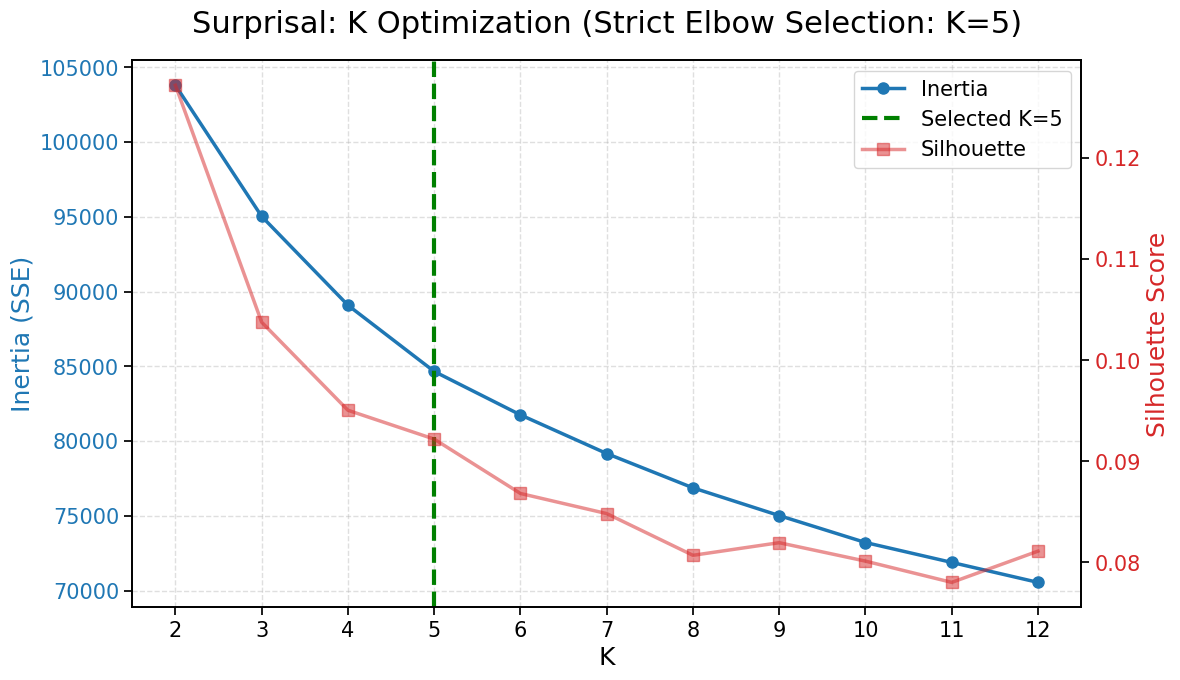

Running KMeans with optimal K=5...
Mean ARI over 10 seeds: 0.930
Saved cluster 0 plot to: /Users/qgroup/Desktop/final_draft/figures/surprisal_cluster_0.png


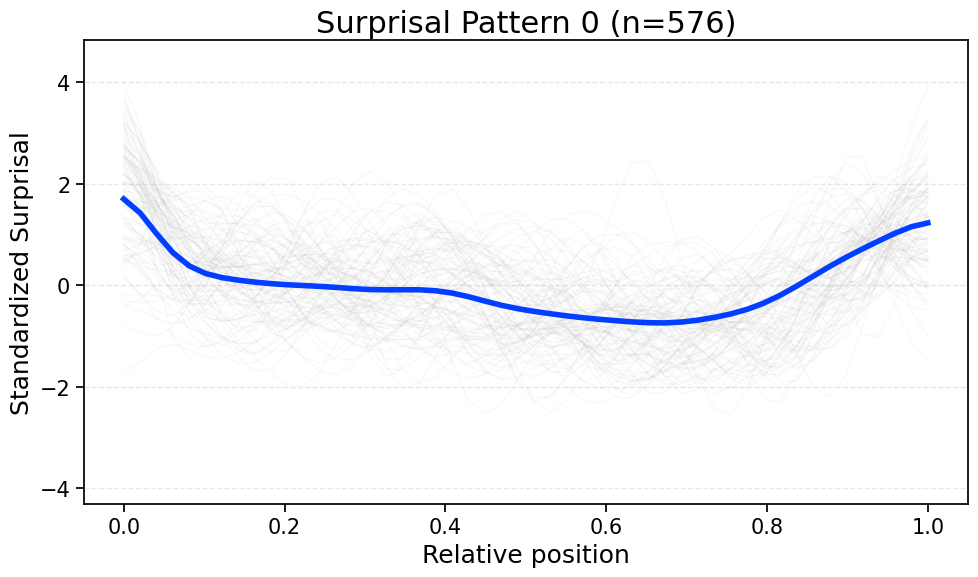

Saved cluster 1 plot to: /Users/qgroup/Desktop/final_draft/figures/surprisal_cluster_1.png


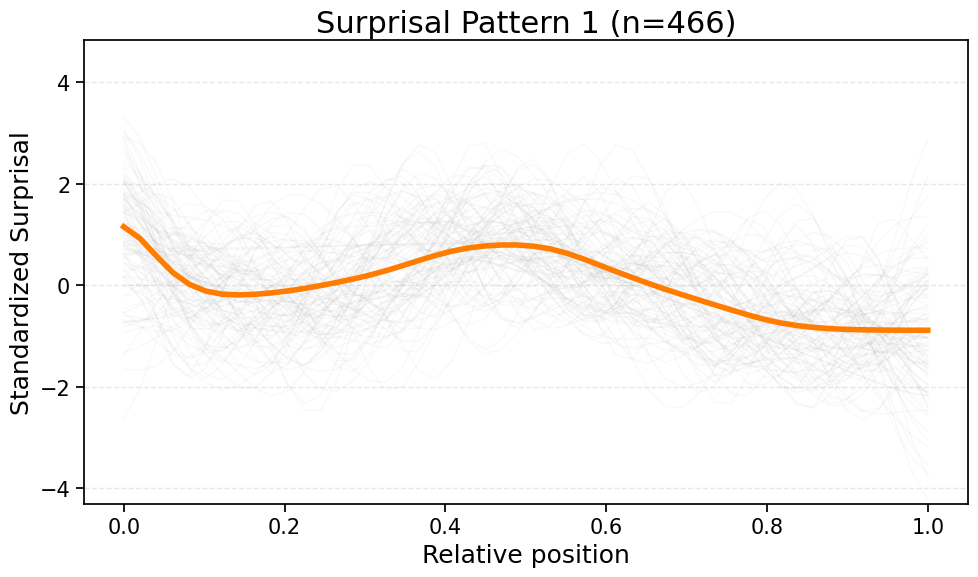

Saved cluster 2 plot to: /Users/qgroup/Desktop/final_draft/figures/surprisal_cluster_2.png


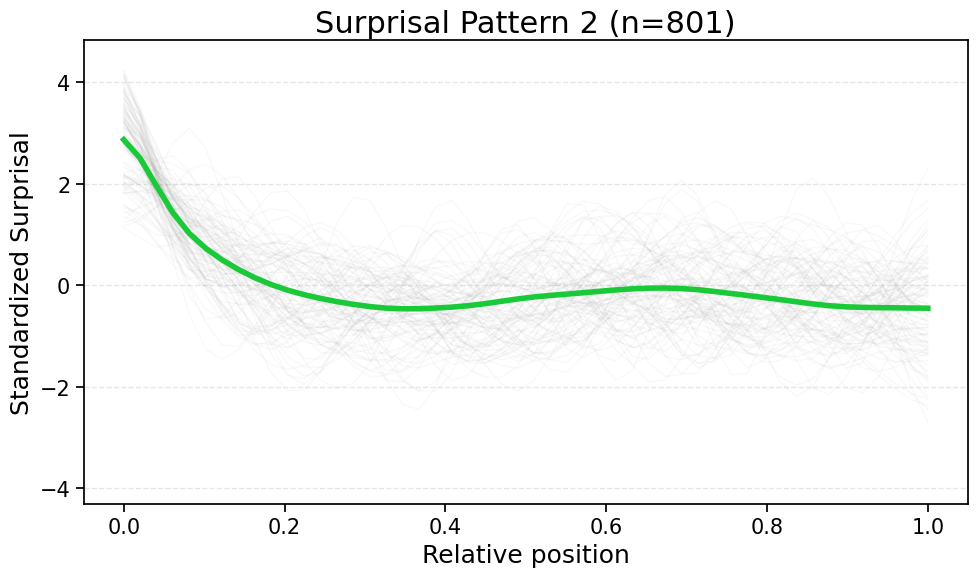

Saved cluster 3 plot to: /Users/qgroup/Desktop/final_draft/figures/surprisal_cluster_3.png


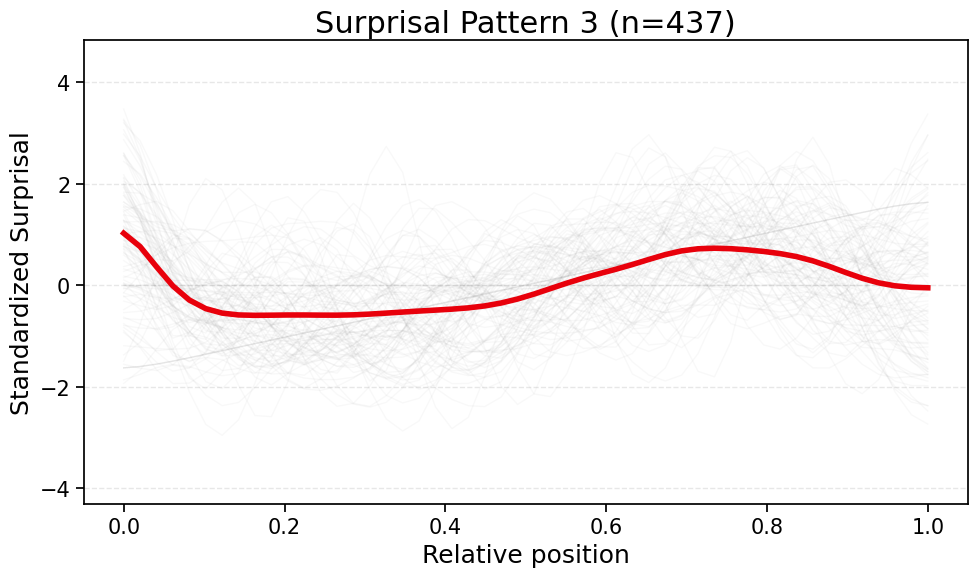

Saved cluster 4 plot to: /Users/qgroup/Desktop/final_draft/figures/surprisal_cluster_4.png


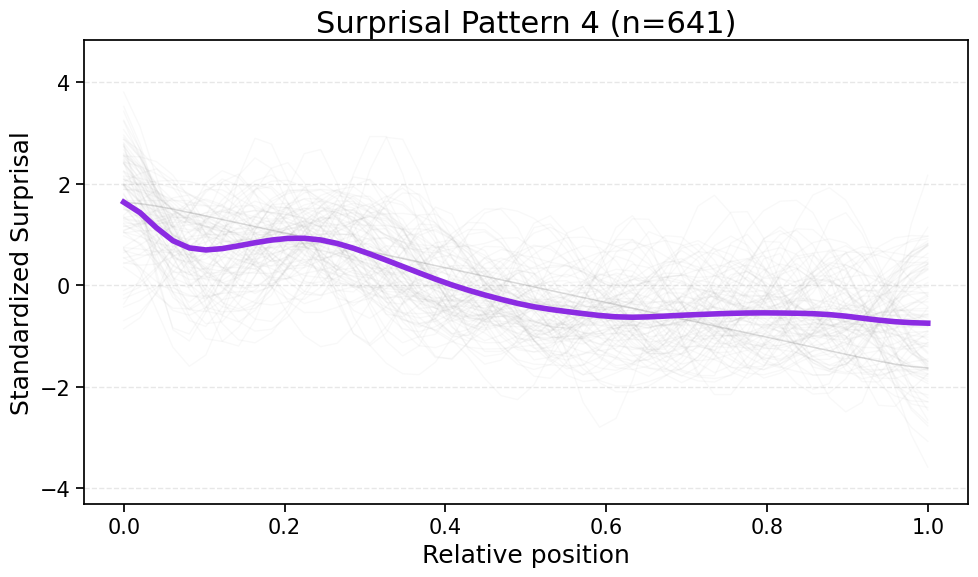

In [42]:
import os
import pandas as pd
import numpy as np
import ast
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator

# ==========================================
# 1. Configuration: Paths and Filenames
# ==========================================
feat_file = f"{base_path}/short_novel_with_all_curves_50.csv"

# Output paths
out_surp_kplot = f"{base_path}/figures/surprisal_k_optimization_strict.png"
out_surp_csv   = f"{base_path}/short_novel_clustered_surprisal_kneed.csv"
cluster_folder = f"{base_path}/figures"
os.makedirs(cluster_folder, exist_ok=True)

K_MIN, K_MAX = 2, 12

# ==========================================
# 2. Data Loading and Vector Transformation
# ==========================================
print(f"Loading: {feat_file}")
df = pd.read_csv(feat_file)

def safe_vec(x):
    if isinstance(x, list): return x
    if not isinstance(x, str) or not x.strip(): return []
    try:
        v = ast.literal_eval(x)
        return list(v) if isinstance(v, (list, tuple)) else []
    except Exception: return []

target_col = "surprisal_curve_50_smooth"
df["surp_curve"] = df[target_col].apply(safe_vec)

# Filter for data with length of 50
valid = df["surp_curve"].map(len) == 50
df = df[valid].reset_index(drop=True)
print(f"Data shape after filtering: {df.shape}")

# Create data matrix and apply Z-score normalization
X_raw = np.vstack(df["surp_curve"].values)
X_scaled = np.nan_to_num(zscore(X_raw, axis=1))

# ==========================================
# 3. K Range Exploration (Inertia + Silhouette)
# ==========================================
print("Optimizing K...")
k_range = list(range(K_MIN, K_MAX + 1))
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Mathematical Elbow Detection (Kneedle)
kn = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
best_k = kn.knee if kn.knee else k_range[int(np.argmax(silhouettes))]
print(f"{'-'*30}\n★ Best K detected: {best_k}\n{'-'*30}")

# ==========================================
# 4. Visualization: K Optimization (Strict Elbow)
# ==========================================
TITLE_FONT, LABEL_FONT, TICK_FONT, LEGEND_FONT = 22, 18, 15, 15
fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.set_xlabel("K", fontsize=LABEL_FONT)
ax1.set_xticks(k_range)
ax1.tick_params(axis="x", labelsize=TICK_FONT)

# Left Y-axis: Inertia
color1 = "tab:blue"
ax1.set_ylabel("Inertia (SSE)", color=color1, fontsize=LABEL_FONT)
ax1.plot(k_range, inertias, "o-", color=color1, linewidth=2.5, markersize=8, label='Inertia')
ax1.tick_params(axis="y", labelcolor=color1, labelsize=TICK_FONT)
if best_k:
    ax1.axvline(x=best_k, color='green', linestyle='--', linewidth=3, label=f'Selected K={best_k}')

# Right Y-axis: Silhouette
ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("Silhouette Score", color=color2, fontsize=LABEL_FONT)
ax2.plot(k_range, silhouettes, "s-", color=color2, alpha=0.5, linewidth=2.5, markersize=8, label='Silhouette')
ax2.tick_params(axis="y", labelcolor=color2, labelsize=TICK_FONT)

plt.title(f"Surprisal: K Optimization (Strict Elbow Selection: K={best_k})", fontsize=TITLE_FONT, pad=20)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=LEGEND_FONT)
ax1.grid(True, axis="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(out_surp_kplot, dpi=300)
plt.show()

# ==========================================
# 5. Final Clustering and Stability Check
# ==========================================
print(f"Running KMeans with optimal K={best_k}...")
kmeans_surp = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df["cluster_surp"] = kmeans_surp.fit_predict(X_scaled)
df.to_csv(out_surp_csv, index=False, encoding="utf-8-sig")

# Evaluate Stability
n_seeds = 10
ari_list = []
for seed in range(10, 10 + n_seeds):
    km_test = KMeans(n_clusters=best_k, random_state=seed, n_init=20)
    test_labels = km_test.fit_predict(X_scaled)
    ari_list.append(adjusted_rand_score(df["cluster_surp"], test_labels))

print(f"Mean ARI over {n_seeds} seeds: {np.mean(ari_list):.3f}")

# ==========================================
# 6. Archetype Visualization (Fixed Y-axis & Individual Save/Show)
# ==========================================
plt.rcParams.update({
    "font.size": 14, "axes.titlesize": 22, "axes.labelsize": 18,
    "xtick.labelsize": 15, "ytick.labelsize": 15, "legend.fontsize": 15
})

global_y_min, global_y_max = X_scaled.min() - 0.1, X_scaled.max() + 0.1
colors = sns.color_palette("bright", best_k)
x_axis = np.linspace(0, 1, X_scaled.shape[1])

for k in range(best_k):
    sub_indices = df[df["cluster_surp"] == k].index
    if len(sub_indices) == 0: continue
    
    C = X_scaled[df["cluster_surp"] == k]
    centroid = C.mean(axis=0)

    plt.figure(figsize=(10, 6))
    plt.ylim(global_y_min, global_y_max)
    
    # Plot background curves (sampled)
    sample_size = min(100, len(C))
    plot_C = C[np.random.choice(len(C), sample_size, replace=False)] if len(C) > sample_size else C
    for curve in plot_C:
        plt.plot(x_axis, curve, color="gray", alpha=0.05, linewidth=1)

    # Plot centroid curve
    plt.plot(x_axis, centroid, color=colors[k], linewidth=4)
    
    plt.title(f"Surprisal Pattern {k} (n={len(C)})")
    plt.xlabel("Relative position")
    plt.ylabel("Standardized Surprisal")
    plt.grid(True, axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    
    # Save and Show
    out_path = f"{cluster_folder}/surprisal_cluster_{k}.png"
    plt.savefig(out_path, dpi=300)
    print(f"Saved cluster {k} plot to: {out_path}")
    plt.show() # Now displays in output

In [43]:
import pandas as pd
import numpy as np
import ast

# ==========================================
# 1. Configuration: Paths and Filenames
# ==========================================
clustered_file = f"{base_path}/short_novel_clustered_surprisal_kneed.csv"
out_stats_csv = f"{base_path}/surprisal_cluster_shape_stats.csv"

print(f"Loading clustered data from: {clustered_file}")
df = pd.read_csv(clustered_file)

def safe_vec(x):
    """
    Safely converts string representations of lists back into Python lists.
    """
    if isinstance(x, list):
        return x
    if not isinstance(x, str) or not x.strip():
        return []
    try:
        v = ast.literal_eval(x)
        if isinstance(v, (list, tuple)):
            return list(v)
        return []
    except Exception:
        return []

# --- Step 1: Reconstruct Normalized 50-bin Trajectories ---
# This mirrors the row-wise Z-score normalization used in the clustering process.
surp_col = "surprisal_curve_50_smooth"
df["surp_curve"] = df[surp_col].apply(safe_vec)

# Ensure only valid 50-bin curves are processed
valid = df["surp_curve"].map(len) == 50
df = df[valid].reset_index(drop=True)

curves = np.vstack(df["surp_curve"].values)   # Matrix shape: (N, 50)

# Apply row-wise Z-score normalization: (x - mean) / std
# This ensures that intensity is relative to each story's own baseline.
curves_z = (curves - curves.mean(axis=1, keepdims=True)) / curves.std(axis=1, keepdims=True)
curves_z = np.nan_to_num(curves_z)

# --- Step 2: Calculate Story-level Shape Descriptors ---
n_points = curves_z.shape[1]

# Intensity: Maximum Z-score achieved in the narrative
max_vals = curves_z.max(axis=1)

# Timing: Relative position of the peak (scaled from 0.0 to 1.0)
peak_pos = curves_z.argmax(axis=1) / (n_points - 1) 

# Baseline and Variation
means = curves_z.mean(axis=1)
stds = curves_z.std(axis=1)

df["surp_max"] = max_vals
df["surp_peak_pos"] = peak_pos
df["surp_mean"] = means
df["surp_std"] = stds

# --- Step 3: Generate Summary Statistics by Cluster ---
cluster_col = "cluster_surp"

# Aggregating Mean and Standard Deviation for each descriptor per cluster
grouped = df.groupby(cluster_col).agg(
    n_stories = ("surp_max", "size"),
    max_intensity_mean = ("surp_max", "mean"),
    max_intensity_sd   = ("surp_max", "std"),
    peak_position_mean = ("surp_peak_pos", "mean"),
    peak_position_sd   = ("surp_peak_pos", "std"),
    z_mean_avg         = ("surp_mean", "mean"),
    z_mean_sd          = ("surp_mean", "std"),
    z_std_avg          = ("surp_std", "mean"),
    z_std_sd           = ("surp_std", "std"),
)

print("\n=== Surprisal Archetype Shape Statistics ===")
print(grouped)

# Export results for use in the "Results" section (Table 2)
grouped.to_csv(out_stats_csv, index=True, encoding="utf-8-sig")
print(f"\nSaved cluster shape stats to: {out_stats_csv}")

Loading clustered data from: /Users/qgroup/Desktop/final_draft/short_novel_clustered_surprisal_kneed.csv

=== Surprisal Archetype Shape Statistics ===
              n_stories  max_intensity_mean  max_intensity_sd  \
cluster_surp                                                    
0                   576            2.416571          0.622993   
1                   466            2.072340          0.521652   
2                   801            2.952508          0.718992   
3                   437            2.080386          0.636090   
4                   641            2.187176          0.514725   

              peak_position_mean  peak_position_sd    z_mean_avg  \
cluster_surp                                                       
0                       0.404549          0.449972  4.075423e-17   
1                       0.310633          0.268816 -1.159676e-17   
2                       0.026039          0.111584  4.348885e-18   
3                       0.500630          0.380193 -4

/var/folders/17/8f0ydqmd0vb_k2j226w720g00000gn/T/ipykernel_82573/1527788669.py:43: RuntimeWarning: invalid value encountered in divide
  curves_z = (curves - curves.mean(axis=1, keepdims=True)) / curves.std(axis=1, keepdims=True)


In [44]:
import pandas as pd
import numpy as np
import ast
from scipy.stats import f_oneway, kruskal

# ==========================================
# 1. Configuration and Data Loading
# ==========================================
# Path to the clustered surprisal data
clustered_file = f"{base_path}/short_novel_clustered_surprisal_kneed.csv"

print(f"Loading data: {clustered_file}")
df = pd.read_csv(clustered_file)

def safe_vec(x):
    """
    Safely converts string-formatted lists into Python list objects.
    Ensures data integrity for vector-based columns.
    """
    if isinstance(x, list):
        return x
    if not isinstance(x, str) or not x.strip():
        return []
    try:
        v = ast.literal_eval(x)
        if isinstance(v, (list, tuple)):
            return list(v)
        return []
    except Exception:
        return []

# --- Step 1: Reconstruct Normalized 50-bin Surprisal Curves ---
# Re-calculating Z-scored trajectories to ensure consistency with the clustering space.
surp_col = "surprisal_curve_50_smooth"
df["surp_curve"] = df[surp_col].apply(safe_vec)

# Filter for valid trajectories with a fixed length of 50 bins
df = df[df["surp_curve"].map(len) == 50].reset_index(drop=True)

# Stack curves and apply row-wise Z-score normalization
curves = np.vstack(df["surp_curve"].values)
curves_z = (curves - curves.mean(axis=1, keepdims=True)) / curves.std(axis=1, keepdims=True)
curves_z = np.nan_to_num(curves_z)
n_points = curves_z.shape[1]

# --- Step 2: Calculate Shape Descriptors for Statistical Testing ---
# Timing: Relative position of the maximum surprisal peak (normalized 0.0 to 1.0)
df["surp_peak_pos"] = curves_z.argmax(axis=1) / n_points
# Volatility: Standard deviation of the narrative signal intensity
df["surp_std"] = curves_z.std(axis=1)

cluster_col = "cluster_surp"
clusters = sorted(df[cluster_col].unique())

# ==========================================
# 2. Statistical Significance Testing
# ==========================================
# List to aggregate statistical test outputs
test_results = []

def run_tests(var_name):
    """
    Performs parametric (ANOVA) and non-parametric (Kruskal-Wallis) tests 
    to evaluate differences between clusters.
    """
    print(f"\n=== Surprisal: Statistical tests for '{var_name}' by cluster ===")
    
    # Group the descriptor values by their respective clusters
    groups = [df[df[cluster_col] == k][var_name].values for k in clusters]
    
    # 1. One-way ANOVA (Parametric test for mean differences)
    F, p_anova = f_oneway(*groups)
    print(f"ANOVA: F-statistic = {F:.3f}, p-value = {p_anova:.3e}")
    
    # 2. Kruskal-Wallis H-test (Non-parametric test for median/distribution differences)
    H, p_kw = kruskal(*groups)
    print(f"Kruskal-Wallis: H-statistic = {H:.3f}, p-value = {p_kw:.3e}")

    # Append metrics to the result list for export
    test_results.append({
        "Variable": var_name,
        "ANOVA_F": round(F, 4),
        "ANOVA_p": f"{p_anova:.3e}",
        "Kruskal_H": round(H, 4),
        "Kruskal_p": f"{p_kw:.3e}"
    })

# Execute tests for Peak Timing and Signal Volatility
run_tests("surp_peak_pos")
run_tests("surp_std")

# ==========================================
# 3. Export Results to CSV
# ==========================================
output_test_file = f"{base_path}/surprisal_statistical_tests.csv"
results_df = pd.DataFrame(test_results)
results_df.to_csv(output_test_file, index=False, encoding="utf-8-sig")

print(f"\n[Final] Statistical test results successfully saved to: {output_test_file}")

Loading: /Users/qgroup/Desktop/final_draft/short_novel_clustered_surprisal_kneed.csv

=== Surprisal: Statistical tests for surp_peak_pos by cluster ===
ANOVA: F-statistic = 285.579, p-value = 2.023e-207
Kruskal-Wallis: H-statistic = 696.237, p-value = 2.275e-149

=== Surprisal: Statistical tests for surp_std by cluster ===
ANOVA: F-statistic = 16.008, p-value = 5.700e-13
Kruskal-Wallis: H-statistic = 7.265, p-value = 1.225e-01

[Final] Statistical test results saved to: /Users/qgroup/Desktop/final_draft/surprisal_statistical_tests.csv


/var/folders/17/8f0ydqmd0vb_k2j226w720g00000gn/T/ipykernel_82573/2851738560.py:41: RuntimeWarning: invalid value encountered in divide
  curves_z = (curves - curves.mean(axis=1, keepdims=True)) / curves.std(axis=1, keepdims=True)


Loading data from: /Users/qgroup/Desktop/final_draft/short_novel_with_all_curves_50.csv
Total rows: 2921

Processing: Surprisal
Running KMeans (K=5)...
Saved clustered data: /Users/qgroup/Desktop/final_draft/short_novel_clustered_surprisal.csv

[Statistics for Surprisal]
- Average Inter-cluster Distance: 5.4972
- Max Inter-cluster Distance:      7.1778
Saved Heatmap: /Users/qgroup/Desktop/final_draft/figures/surprisal_inter_cluster_distance.png

All processing complete!


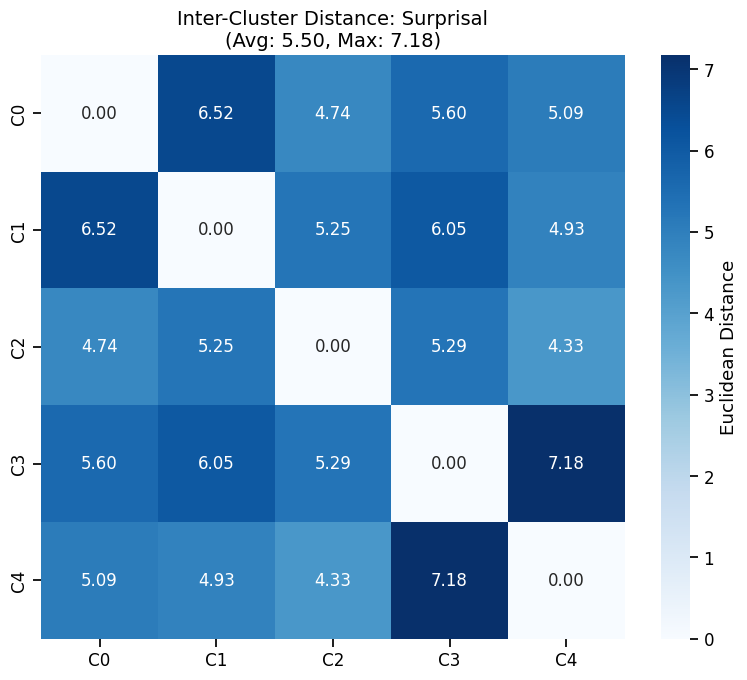

In [45]:
import pandas as pd
import numpy as np
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist, squareform
from scipy.stats import zscore
import os

# ==========================================
# 1. Configuration and Target Definition
# ==========================================
# Path to the input file containing narrative curves
input_file = f"{base_path}/short_novel_with_all_curves_50.csv"

# Configuration for metric analysis (Focusing on Surprisal)
targets = [
    {
        "name": "Surprisal",
        "col": "surprisal_curve_50_smooth",
        "k": 5, # Number of archetypes (Clusters 0-4)
        "out_csv": f"{base_path}/short_novel_clustered_surprisal.csv",
        "out_img": f"{base_path}/figures/surprisal_inter_cluster_distance.png"
    }
]

# ==========================================
# 2. Utility Functions
# ==========================================
def safe_vec(x):
    """
    Safely converts string-formatted lists into Python list objects.
    Ensures that narrative trajectories are properly parsed for analysis.
    """
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return []

def analyze_metric(df, target_info):
    """
    Performs clustering, calculates inter-cluster distances, 
    and generates a distance heatmap for the specified metric.
    """
    name = target_info["name"]
    col = target_info["col"]
    k = target_info["k"]
    
    print(f"\n" + "="*40)
    print(f"Processing Metric: {name}")
    print(f"="*40)
    
    # 1. Data Parsing and Cleaning
    if col not in df.columns:
        print(f"Error: Column '{col}' not found. Skipping...")
        return

    # Create a working copy of the dataframe
    df_work = df.copy()
    df_work["vec"] = df_work[col].apply(safe_vec)
    
    # Filter for narratives that have a consistent length of 50 bins
    valid_mask = df_work["vec"].map(len) == 50
    df_work = df_work[valid_mask].reset_index(drop=True)
    
    if len(df_work) == 0:
        print("Error: No valid data found (required length = 50).")
        return

    # Convert to numpy array for numerical processing
    X_raw = np.vstack(df_work["vec"].values)
    
    # Z-score Normalization (Essential for morphological/shape-based comparison)
    X_scaled = zscore(X_raw, axis=1)
    X_scaled = np.nan_to_num(X_scaled)
    
    # 2. KMeans Clustering
    print(f"Executing KMeans clustering (K={k})...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    
    # Store cluster assignments (Column name: cluster_surprisal)
    cluster_col_name = f"cluster_{name.lower().replace(' ', '_')}"
    df_work[cluster_col_name] = labels
    
    # Drop the temporary 'vec' column and save clustered data
    df_save = df_work.drop(columns=["vec"])
    df_save.to_csv(target_info["out_csv"], index=False, encoding="utf-8-sig")
    print(f"Clustered data successfully saved to: {target_info['out_csv']}")
    
    # 3. Centroid Calculation and Distance Metrics
    centroids = []
    cluster_ids = sorted(np.unique(labels))
    
    for cid in cluster_ids:
        # Calculate the mean vector for each cluster
        mean_vec = X_scaled[labels == cid].mean(axis=0)
        centroids.append(mean_vec)
        
    centroids = np.array(centroids)
    
    # Calculate Euclidean distance matrix between cluster centroids
    dist_matrix = squareform(pdist(centroids, metric='euclidean'))
    
    # Calculate average and max distances using the upper triangle (excluding identity)
    avg_dist = np.mean(dist_matrix[np.triu_indices_from(dist_matrix, k=1)])
    max_dist = np.max(dist_matrix)
    
    print(f"\n[Clustering Statistics for {name}]")
    print(f"- Average Inter-cluster Distance: {avg_dist:.4f}")
    print(f"- Maximum Inter-cluster Distance: {max_dist:.4f}")
    
    # 4. Heatmap Visualization
    plt.figure(figsize=(8, 7))
    sns.set_context("notebook", font_scale=1.1)
    
    labels_str = [f"C{i}" for i in cluster_ids]
    ax = sns.heatmap(dist_matrix, annot=True, fmt=".2f", cmap="Blues",
                     xticklabels=labels_str, yticklabels=labels_str,
                     annot_kws={"size": 12},
                     cbar_kws={'label': 'Euclidean Distance'})
    
    plt.title(f"Inter-Cluster Distance Heatmap: {name}\n(Avg: {avg_dist:.2f}, Max: {max_dist:.2f})", fontsize=14)
    plt.tight_layout()
    plt.savefig(target_info["out_img"])
    print(f"Heatmap visualization saved to: {target_info['out_img']}")

# ==========================================
# 3. Main Execution
# ==========================================
def main():
    if not os.path.exists(input_file):
        print(f"Error: Input file not found at {input_file}")
        return
        
    print(f"Loading dataset: {input_file}")
    df = pd.read_csv(input_file)
    print(f"Total rows loaded: {len(df)}")
    
    for target in targets:
        try:
            analyze_metric(df, target)
        except Exception as e:
            print(f"Error processing {target['name']}: {e}")
            
    print("\n" + "="*40)
    print("All narrative archetype processing complete!")

if __name__ == "__main__":
    main()

In [46]:
import pandas as pd
import numpy as np
import ast
from scipy.stats import zscore
from scipy.spatial.distance import euclidean

# ==========================================
# 1. Configuration
# ==========================================
# Input file containing the clustering results
input_clustered_file = f"{base_path}/short_novel_clustered_surprisal_kneed.csv"
# Output file for representative stories
output_rep_csv = f"{base_path}/surprisal_representative_prototypes.csv"

# ==========================================
# 2. Utility Functions
# ==========================================
def safe_vec(x):
    """
    Safely converts string-formatted lists back into Python list objects.
    """
    if isinstance(x, list): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return []
    return []

def main():
    print("Loading clustered data...")
    # Load the clustered dataset
    df = pd.read_csv(input_clustered_file)
    
    # Define the surprisal curve column name
    surp_col = "surprisal_curve_50_smooth"
    cluster_col = "cluster_surp"
    
    # Parse vector strings into lists
    df["vec_s"] = df[surp_col].apply(safe_vec)
    
    # Filter to ensure only valid 50-bin curves are processed
    df = df[df["vec_s"].map(len) == 50].reset_index(drop=True)
    
    # Matrix creation and Z-score normalization for distance calculation
    # We use row-wise normalization to focus on the 'shape' of the curve
    X_raw = np.vstack(df["vec_s"].values)
    X_scaled = np.nan_to_num(zscore(X_raw, axis=1))
    
    clusters = sorted(df[cluster_col].unique())
    rep_list = []
    
    print("Identifying prototypical works for each cluster...")
    for k in clusters:
        # Get indices for stories belonging to the current cluster
        indices = df.index[df[cluster_col] == k].tolist()
        
        # Calculate the Centroid (Mean Vector) of the cluster in the scaled space
        cluster_vecs = X_scaled[indices]
        centroid = cluster_vecs.mean(axis=0)
        
        # Calculate Euclidean distance between each story in the cluster and the centroid
        distances = []
        for i, idx in enumerate(indices):
            d = euclidean(cluster_vecs[i], centroid)
            distances.append((d, idx))
            
        # Sort by distance (Ascending) and select Top 10
        distances.sort(key=lambda x: x[0])
        top_10 = distances[:10]
        
        # Extract metadata for the representative stories
        for rank, (dist, idx) in enumerate(top_10):
            row = df.loc[idx]
            rep_list.append({
                "cluster": k,
                "rank": rank + 1,
                "distance_to_centroid": round(dist, 4),
                "isbn": row.get("isbn", ""), # ISBN included as requested
                "title": row.get("story_title", row.get("title", "Unknown")),
                "author": row.get("author", row.get("작가", "Unknown")),
                "text_snippet": str(row.get("text", ""))[:200] # Snippet of the text for verification
            })

    # Save the representative stories to CSV
    # utf-8-sig ensures Korean characters are displayed correctly in Excel
    result_df = pd.DataFrame(rep_list)
    result_df.to_csv(output_rep_csv, index=False, encoding='utf-8-sig')
    
    print("=" * 40)
    print(f"Extraction Complete!")
    print(f"Representative works saved to: {output_rep_csv}")
    print("=" * 40)

if __name__ == "__main__":
    main()

Loading clustered data...
Identifying prototypical works for each cluster...
Extraction Complete!
Representative works saved to: /Users/qgroup/Desktop/final_draft/surprisal_representative_prototypes.csv


Loading data for Extended Acid Test...
Using columns: Surprisal, Coherence, semantic_shift_curve_50_smooth
Analyzing peak interactions across all clusters...

=== Summary Statistics (At Peak Surprisal) ===
   Cluster    N  Coherence_Mean  Coherence_P  Semantic_Mean  Semantic_P
0        0  576         -0.4413       0.0000        -0.0564      0.2350
1        1  466         -0.1896       0.0000         0.1489      0.0011
2        2  801         -0.7748       0.0000        -0.5965      0.0000
3        3  437         -0.1761       0.0002         0.1751      0.0001
4        4  641         -0.4392       0.0000         0.0213      0.6413
Saved Coherence plot: /Users/qgroup/Desktop/final_draft/figures/acid_test_coherence_all_clusters.png
Saved Semantic Shift plot: /Users/qgroup/Desktop/final_draft/figures/acid_test_semantic_all_clusters.png


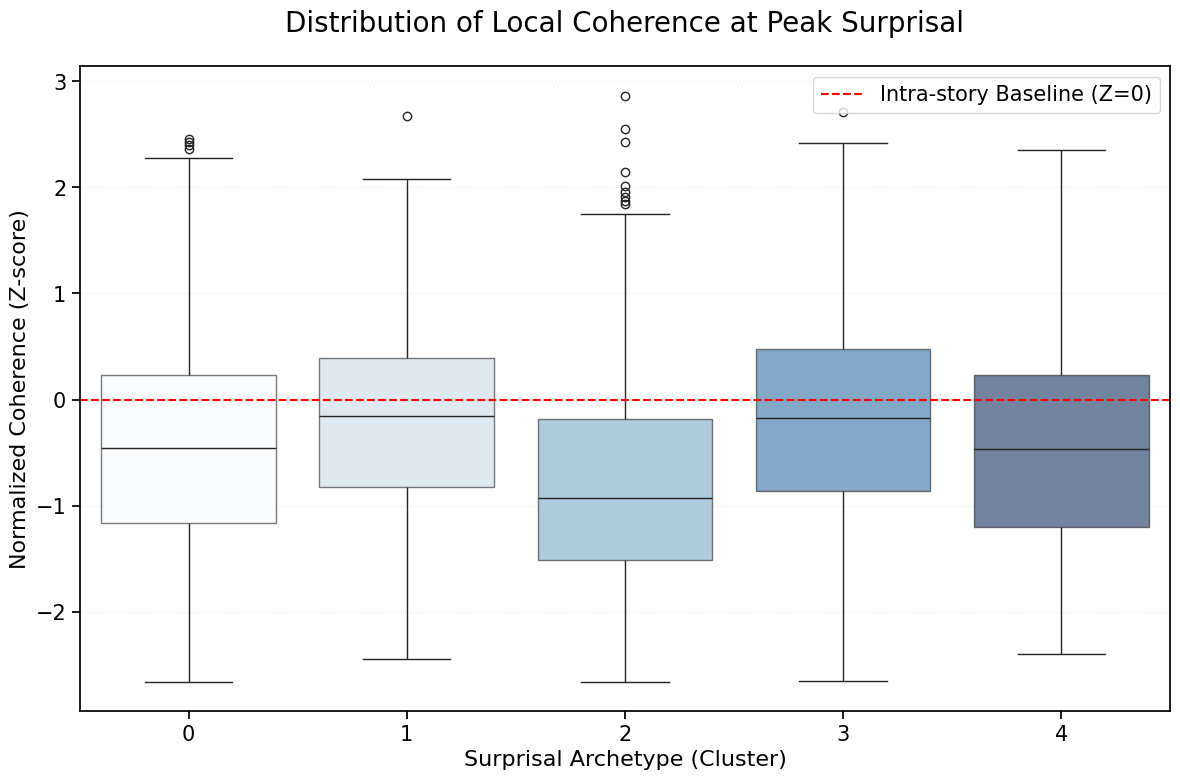

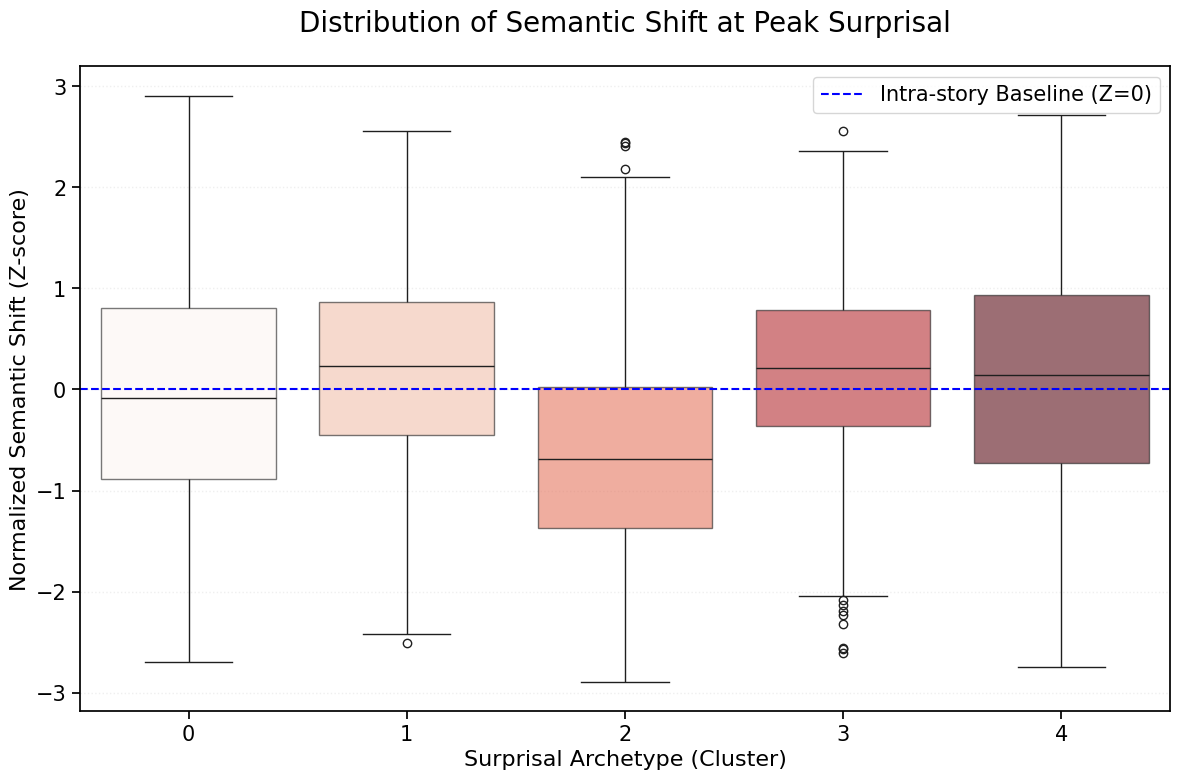

In [47]:
import pandas as pd
import numpy as np
import ast
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 1. Configuration and Paths
# ==========================================
# Input files: features and cluster assignments
feat_file = f"{base_path}/short_novel_with_all_features_50.csv"
clust_file = f"{base_path}/short_novel_clustered_surprisal.csv"

# Output paths for visualization and statistical results
out_img_coh = f"{base_path}/figures/acid_test_coherence_all_clusters.png"
out_img_sem = f"{base_path}/figures/acid_test_semantic_all_clusters.png"
out_csv = f"{base_path}/acid_test_stats_full.csv"

# ==========================================
# 2. Utility Functions
# ==========================================
def safe_vec(x):
    """Safely converts string-formatted lists into Python list objects."""
    if isinstance(x, list): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return []
    return []

def get_z_score_norm(vec):
    """Performs story-level Z-score normalization for internal consistency."""
    arr = np.array(vec)
    if np.std(arr) == 0: return arr * 0
    return (arr - np.mean(arr)) / np.std(arr)

def main():
    print("Initializing Extended Acid Test Analysis...")
    if not os.path.exists(feat_file) or not os.path.exists(clust_file):
        print("Error: Required CSV files not found.")
        return

    df_feat = pd.read_csv(feat_file)
    df_clust = pd.read_csv(clust_file)

    # Automatic detection of Semantic Shift column (handles naming variations)
    sem_col = "semantic_shift_curve_50_smooth"
    if sem_col not in df_feat.columns:
        candidates = [c for c in df_feat.columns if "semantic" in c or "topic" in c]
        if candidates: sem_col = candidates[0]
    
    print(f"Targeting columns: Surprisal, Coherence, and {sem_col}")

    # Parse trajectory vectors
    df_feat["s_curve"] = df_feat["surprisal_curve_50_smooth"].apply(safe_vec)
    df_feat["c_curve"] = df_feat["coherence_curve_50_smooth"].apply(safe_vec)
    df_feat["m_curve"] = df_feat[sem_col].apply(safe_vec)

    # Filter for valid 50-bin trajectories and align dataframes
    valid_mask = df_feat["s_curve"].map(len) == 50
    df_valid = df_feat[valid_mask].reset_index(drop=True)
    min_len = min(len(df_valid), len(df_clust))
    df_valid = df_valid.iloc[:min_len].copy()
    
    # Merge cluster assignments
    df_valid["cluster"] = df_clust.iloc[:min_len]["cluster_surprisal"].values

    # ==========================================
    # 3. Peak-Locked Analysis (Global Investigation)
    # ==========================================
    clusters = sorted(df_valid["cluster"].unique())
    records_coh, records_sem, stats_summary = [], [], []

    print("Analyzing micro-dynamics at the moment of peak surprisal...")
    
    for k in clusters:
        sub_df = df_valid[df_valid["cluster"] == k]
        vals_c, vals_m = [], []
        
        for _, row in sub_df.iterrows():
            s, c, m = row["s_curve"], row["c_curve"], row["m_curve"]
            if len(s) < 50: continue
            
            # 1. Intra-story normalization
            s_norm, c_norm, m_norm = get_z_score_norm(s), get_z_score_norm(c), get_z_score_norm(m)
            
            # 2. Robust Peak Detection
            # Skipping the first 2 bins to avoid initialization artifacts
            search_start = 2
            peak_idx = np.argmax(s_norm[search_start:]) + search_start if len(s_norm) > search_start else np.argmax(s_norm)
            
            # 3. Value Extraction at t=0 (The Surprisal Event)
            val_c, val_m = c_norm[peak_idx], m_norm[peak_idx]
            vals_c.append(val_c)
            vals_m.append(val_m)
            
            # Accumulate data for long-format visualization
            records_coh.append({"Cluster": k, "Value": val_c, "Type": "Coherence"})
            records_sem.append({"Cluster": k, "Value": val_m, "Type": "Semantic Shift"})

        # Statistical Inference (One-sample T-test against story baseline 0)
        t_c, p_c = ttest_1samp(vals_c, 0)
        t_m, p_m = ttest_1samp(vals_m, 0)
        
        stats_summary.append({
            "Cluster": k,
            "N": len(vals_c),
            "Coherence_Mean": np.mean(vals_c),
            "Coherence_P": p_c,
            "Semantic_Mean": np.mean(vals_m),
            "Semantic_P": p_m
        })

    # Save summary statistics
    stats_df = pd.DataFrame(stats_summary)
    stats_df.to_csv(out_csv, index=False)
    print("\n=== Summary Statistics: Peak-Locked Values (t=0) ===")
    print(stats_df.round(4))

    # ==========================================
    # 4. Visualization (Distribution Comparison)
    # ==========================================
    # Aesthetic configuration for Ph.D. dissertation quality
    TITLE_SIZE, LABEL_SIZE, TICK_SIZE, LEGEND_SIZE = 20, 16, 15, 15

    # (1) Coherence Distribution Plot
    plt.figure(figsize=(12, 8))
    df_plot_c = pd.DataFrame(records_coh)
    sns.boxplot(data=df_plot_c, x="Cluster", y="Value", hue="Cluster", palette="Blues", legend=False,
                showfliers=True, boxprops=dict(alpha=0.6))
    
    plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label="Intra-story Baseline (Z=0)")
    plt.title("Local Coherence Deviation at Peak Surprisal", fontsize=TITLE_SIZE, pad=25)
    plt.ylabel("Normalized Coherence (Z-score)", fontsize=LABEL_SIZE)
    plt.xlabel("Surprisal Archetype (Cluster)", fontsize=LABEL_SIZE)
    plt.xticks(fontsize=TICK_SIZE); plt.yticks(fontsize=TICK_SIZE)
    plt.legend(loc='upper right', fontsize=LEGEND_SIZE)
    plt.grid(True, axis='y', alpha=0.2, linestyle=':')
    plt.tight_layout(); plt.savefig(out_img_coh, dpi=300)
    print(f"Saved Coherence distribution plot: {out_img_coh}")

    # (2) Semantic Shift Distribution Plot
    plt.figure(figsize=(12, 8))
    df_plot_m = pd.DataFrame(records_sem)
    sns.boxplot(data=df_plot_m, x="Cluster", y="Value", hue="Cluster", palette="Reds", legend=False,
                showfliers=True, boxprops=dict(alpha=0.6))
    
    plt.axhline(0, color='blue', linestyle='--', linewidth=1.5, label="Intra-story Baseline (Z=0)")
    plt.title("Semantic Shift Deviation at Peak Surprisal", fontsize=TITLE_SIZE, pad=25)
    plt.ylabel("Normalized Semantic Shift (Z-score)", fontsize=LABEL_SIZE)
    plt.xlabel("Surprisal Archetype (Cluster)", fontsize=LABEL_SIZE)
    plt.xticks(fontsize=TICK_SIZE); plt.yticks(fontsize=TICK_SIZE)
    plt.legend(loc='upper right', fontsize=LEGEND_SIZE)
    plt.grid(True, axis='y', alpha=0.2, linestyle=':')
    plt.tight_layout(); plt.savefig(out_img_sem, dpi=300)
    print(f"Saved Semantic Shift distribution plot: {out_img_sem}")

if __name__ == "__main__":
    main()

Starting Event-Locked Analysis (Window: ±5)...
Plot saved to: /Users/qgroup/Desktop/final_draft/figures/event_locked_analysis_coherence.png


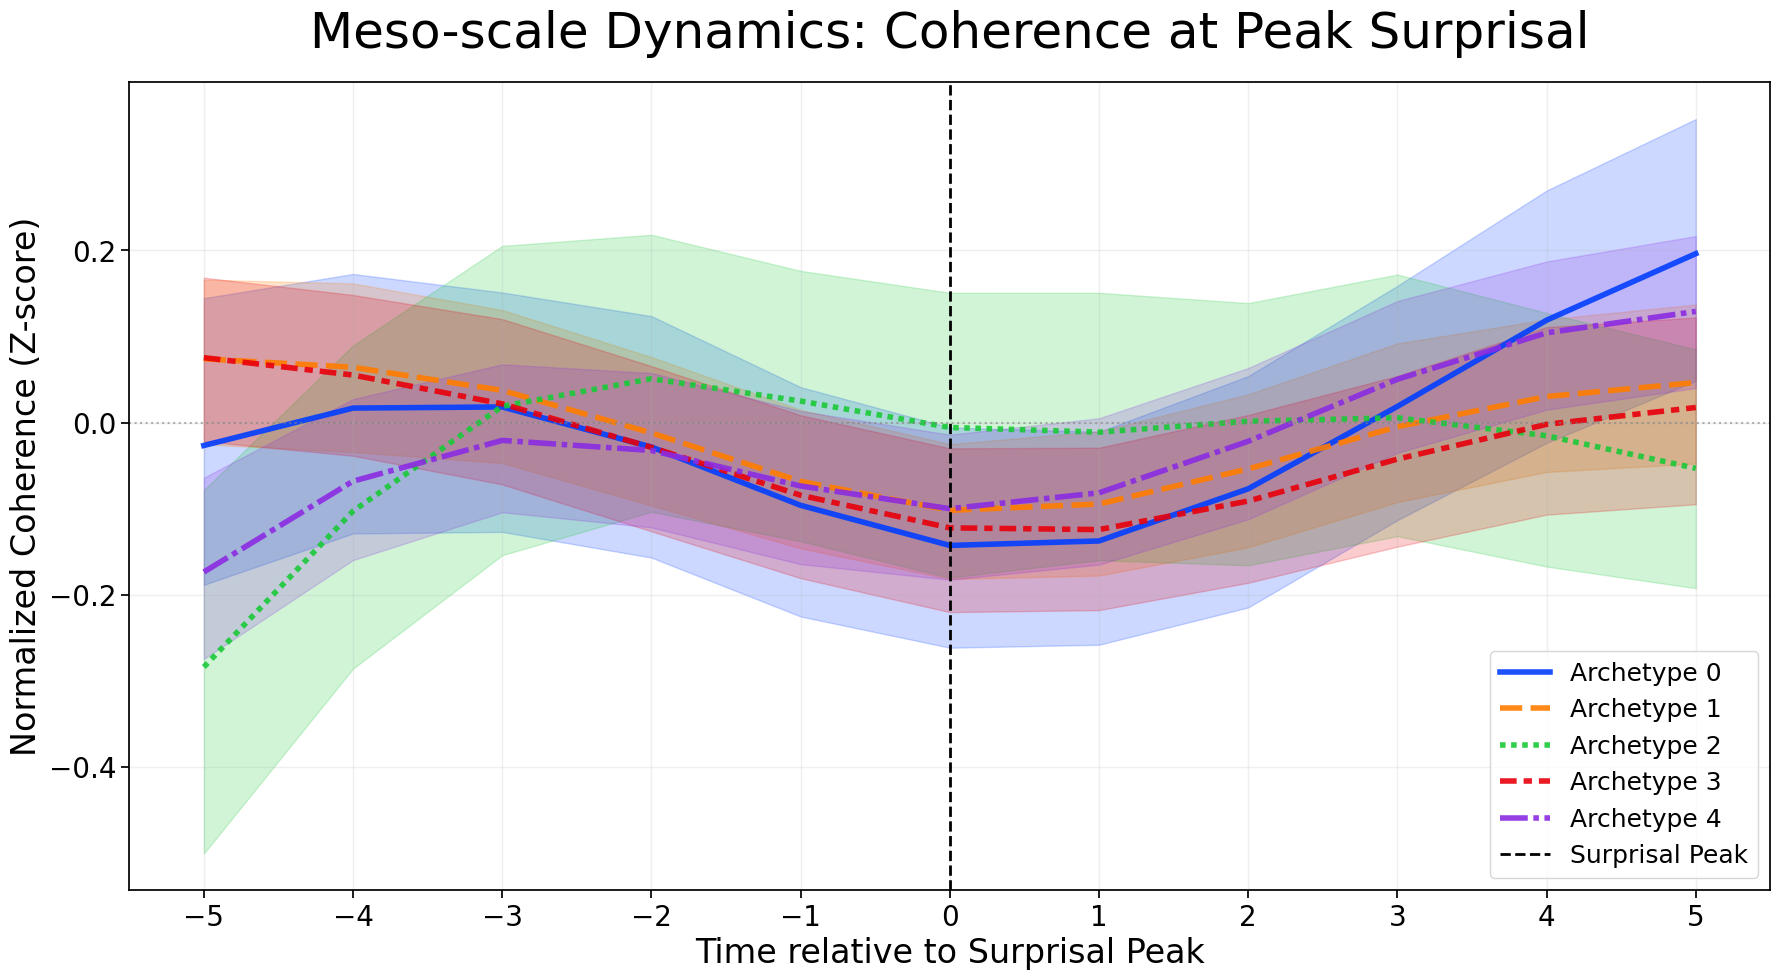

Plot saved to: /Users/qgroup/Desktop/final_draft/figures/event_locked_analysis_semantic.png


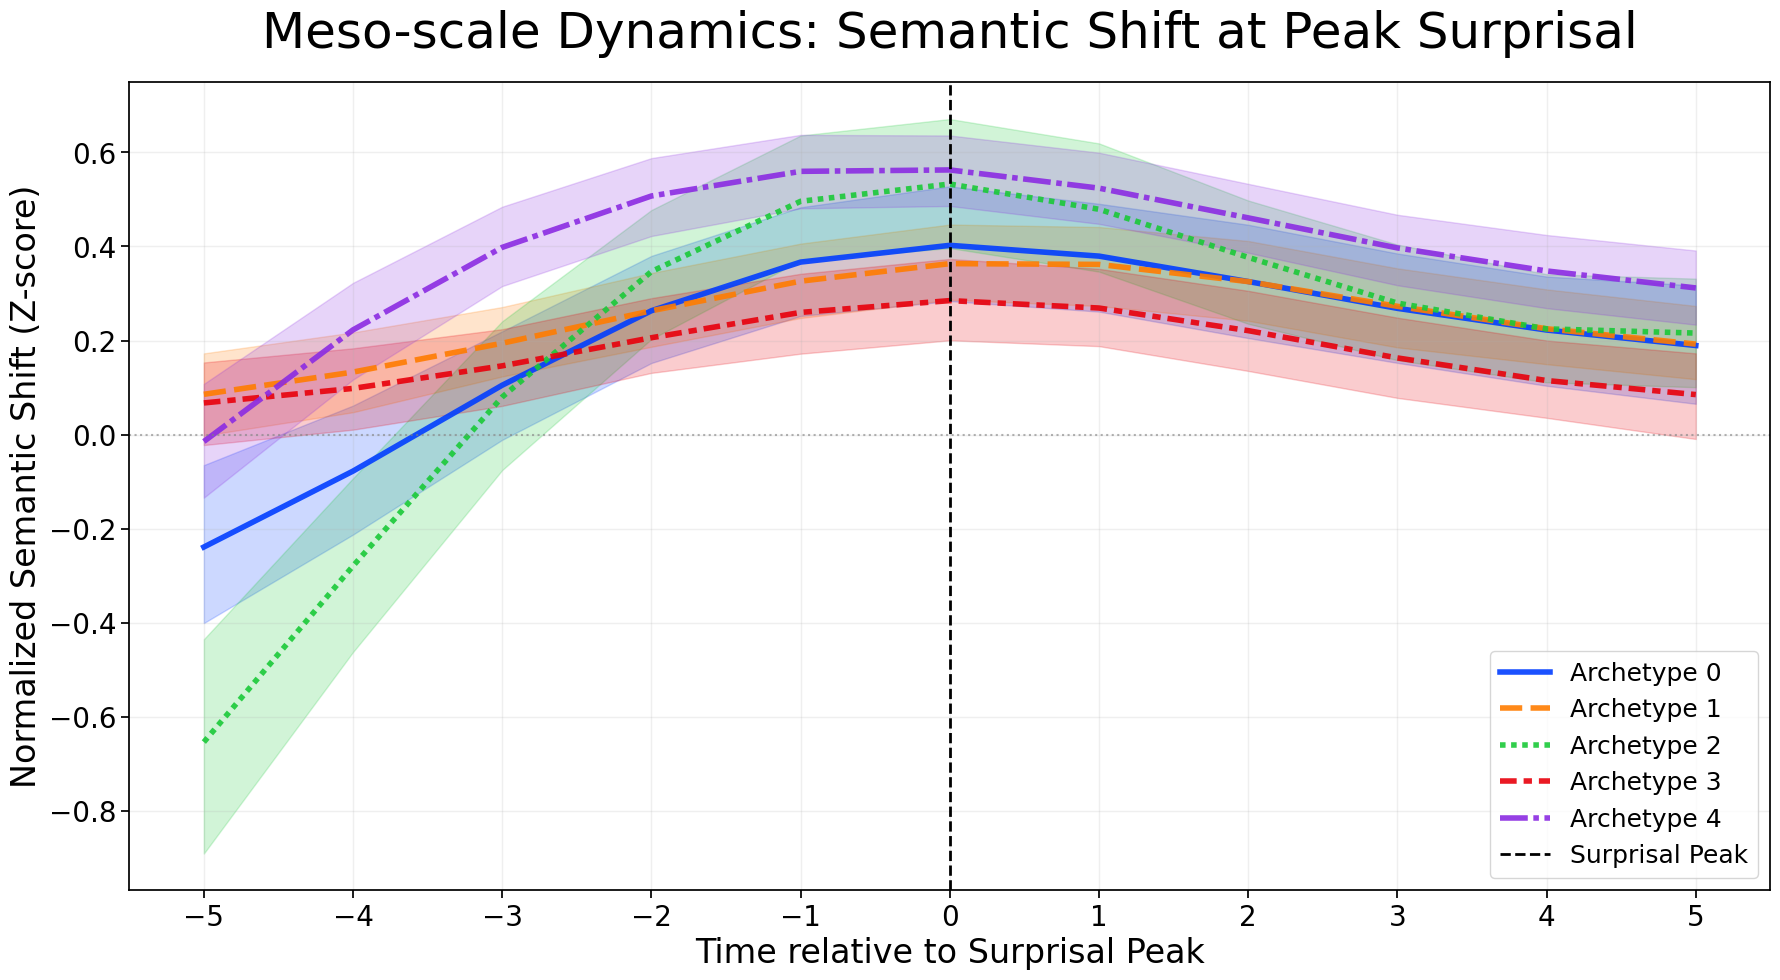

In [48]:
import os
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# ==========================================
# 1. Configuration and Paths
# ==========================================
feat_file = f"{base_path}/short_novel_with_all_features_50.csv"
clust_file = f"{base_path}/short_novel_clustered_surprisal.csv"

# Output file paths for the generated images
out_img_coh = f"{base_path}/figures/event_locked_analysis_coherence.png"
out_img_sem = f"{base_path}/figures/event_locked_analysis_semantic.png"

# Window size W=5 corresponds to a temporal neighborhood of +/- 10%
WINDOW_SIZE = 5 
TITLE_SIZE = 36 
LABEL_SIZE = 24
TICK_SIZE = 20

def safe_vec(x):
    """Safely converts string-formatted lists into Python list objects."""
    if isinstance(x, list): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return []
    return []

def get_z_norm(vec):
    """Performs Z-score normalization on a given vector."""
    arr = np.array(vec)
    if np.std(arr) == 0: return arr * 0
    return (arr - np.mean(arr)) / np.std(arr)

def main():
    print(f"Starting Event-Locked Analysis (Window: ±{WINDOW_SIZE})...")
    
    # Load feature and cluster data
    df_feat = pd.read_csv(feat_file)
    df_clust = pd.read_csv(clust_file)

    # Parse vectors from string format
    df_feat["s_curve"] = df_feat["surprisal_curve_50_smooth"].apply(safe_vec)
    df_feat["c_curve"] = df_feat["coherence_curve_50_smooth"].apply(safe_vec)
    df_feat["m_curve"] = df_feat["semantic_shift_curve_50_smooth"].apply(safe_vec)
    
    # Filter valid rows and merge with cluster labels
    df_valid = df_feat[df_feat["s_curve"].map(len) == 50].reset_index(drop=True)
    min_len = min(len(df_valid), len(df_clust))
    df_valid = df_valid.iloc[:min_len].copy()
    df_valid["cluster"] = df_clust.iloc[:min_len]["cluster_surprisal"].values

    # Step 1: Collect windowed segments around surprisal peaks
    collected = []
    for k in sorted(df_valid["cluster"].unique()):
        sub = df_valid[df_valid["cluster"] == k]
        for _, row in sub.iterrows():
            # Robust peak detection: Identify the maximum surprisal (excluding edge artifacts)
            s_n = get_z_norm(row["s_curve"])
            peak_idx = np.argmax(s_n[2:]) + 2 
            
            start, end = peak_idx - WINDOW_SIZE, peak_idx + WINDOW_SIZE + 1
            # Boundary check: Ensure the window stays within the 50-bin narrative span
            if start < 0 or end > 50: continue
            
            c_seg = get_z_norm(row["c_curve"])[start:end]
            m_seg = get_z_norm(row["m_curve"])[start:end]
            
            x_range = np.arange(-WINDOW_SIZE, WINDOW_SIZE + 1)
            for t, c_val, m_val in zip(x_range, c_seg, m_seg):
                collected.append({
                    "Cluster": f"Archetype {k}", 
                    "Time": t, 
                    "Coherence": c_val, 
                    "Semantic Shift": m_val
                })

    df_plot = pd.DataFrame(collected)

    # ==========================================
    # 2. Visualization and Sequential Output
    # ==========================================
    metrics = [
        {"name": "Coherence", "color": "tab:blue", "path": out_img_coh},
        {"name": "Semantic Shift", "color": "tab:red", "path": out_img_sem}
    ]

    for m in metrics:
        plt.figure(figsize=(18, 10))
        
        # Plot mean trajectories with confidence intervals
        sns.lineplot(
            data=df_plot, x="Time", y=m["name"], hue="Cluster", style="Cluster",
            palette="bright", linewidth=4, alpha=0.9
        )
        
        # Mark the moment of peak surprise (t=0)
        plt.axvline(0, color='black', linestyle='--', linewidth=2, label="Surprisal Peak")
        plt.axhline(0, color='gray', linestyle=':', alpha=0.6)
        
        # Title and Labels
        plt.title(f"Meso-scale Dynamics: {m['name']} at Peak Surprisal", fontsize=TITLE_SIZE, pad=25)
        plt.xlabel("Time relative to Surprisal Peak", fontsize=LABEL_SIZE)
        plt.ylabel(f"Normalized {m['name']} (Z-score)", fontsize=LABEL_SIZE)
        plt.xticks(np.arange(-WINDOW_SIZE, WINDOW_SIZE + 1), fontsize=TICK_SIZE)
        plt.yticks(fontsize=TICK_SIZE)
        
        # Legend configuration
        plt.legend(loc='lower right', fontsize=LABEL_SIZE-6, title_fontsize=LABEL_SIZE-4)
        plt.grid(True, alpha=0.2)
        plt.tight_layout()
        
        # Save high-resolution PNG
        plt.savefig(m["path"], dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {m['path']}")
        
        # ★ Display the plot in the output
        plt.show() 

if __name__ == "__main__":
    main()

Running Individual Windowed Comparison (Coherence vs Semantic Shift)...
Successfully saved plot for Archetype 0 to: /Users/qgroup/Desktop/final_draft/figures/archetype_0_dynamics.png


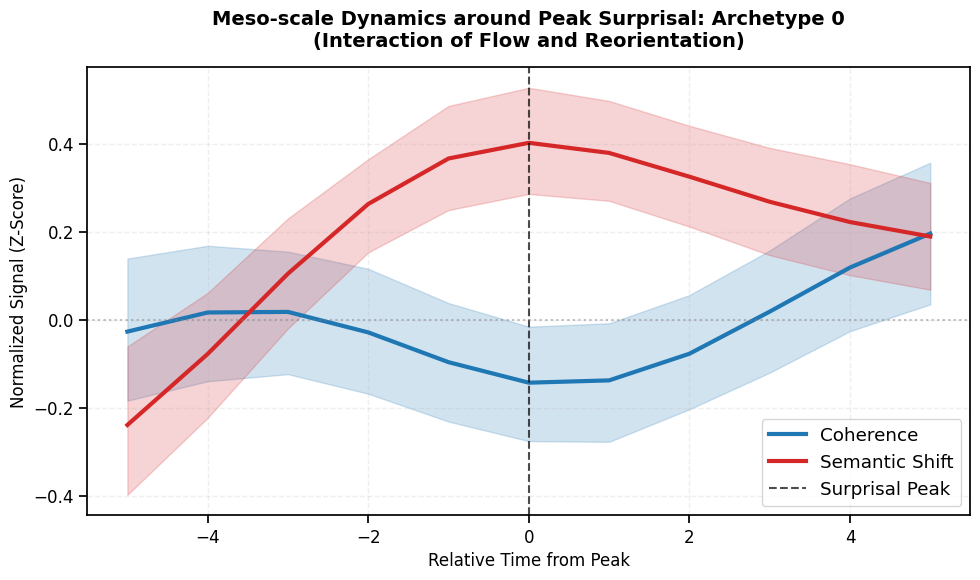

Successfully saved plot for Archetype 1 to: /Users/qgroup/Desktop/final_draft/figures/archetype_1_dynamics.png


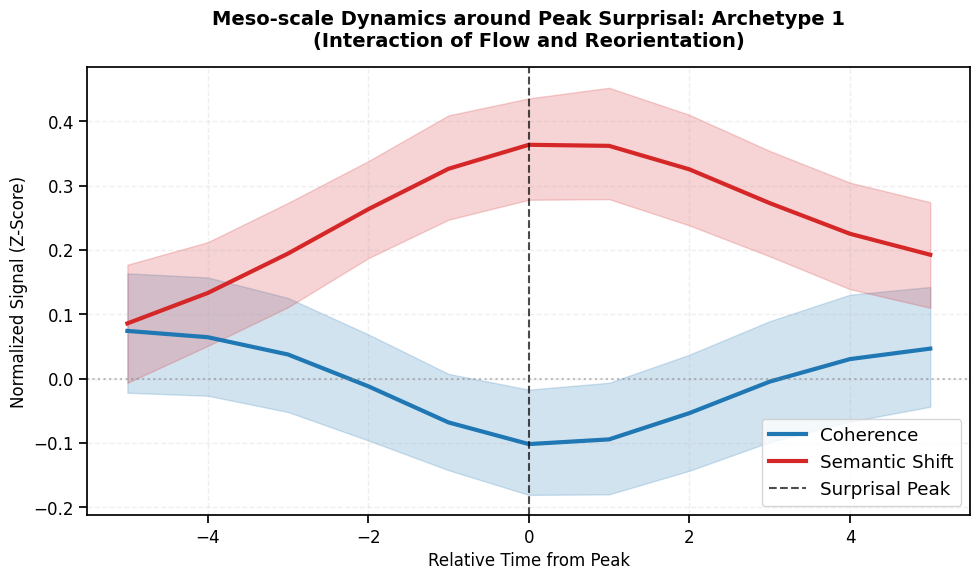

Successfully saved plot for Archetype 2 to: /Users/qgroup/Desktop/final_draft/figures/archetype_2_dynamics.png


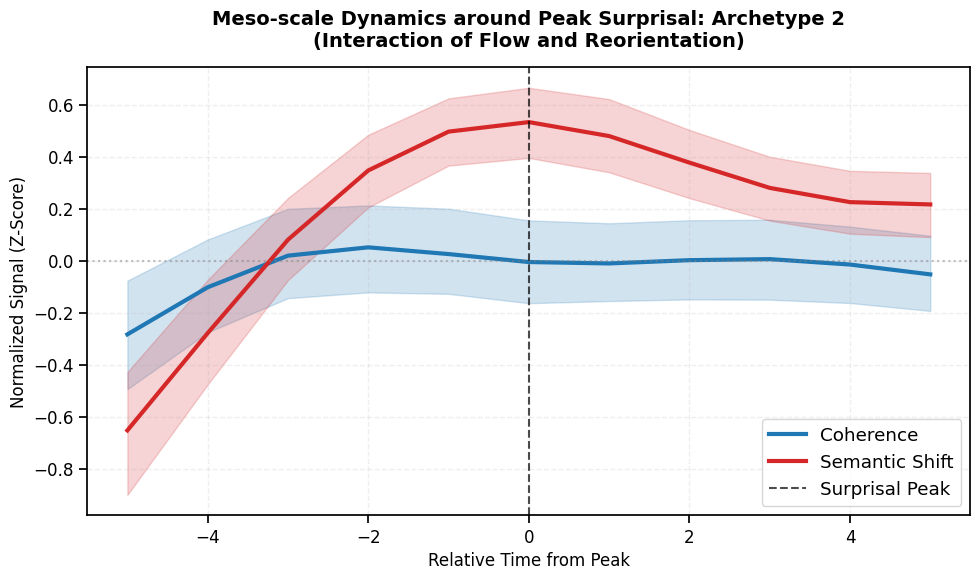

Successfully saved plot for Archetype 3 to: /Users/qgroup/Desktop/final_draft/figures/archetype_3_dynamics.png


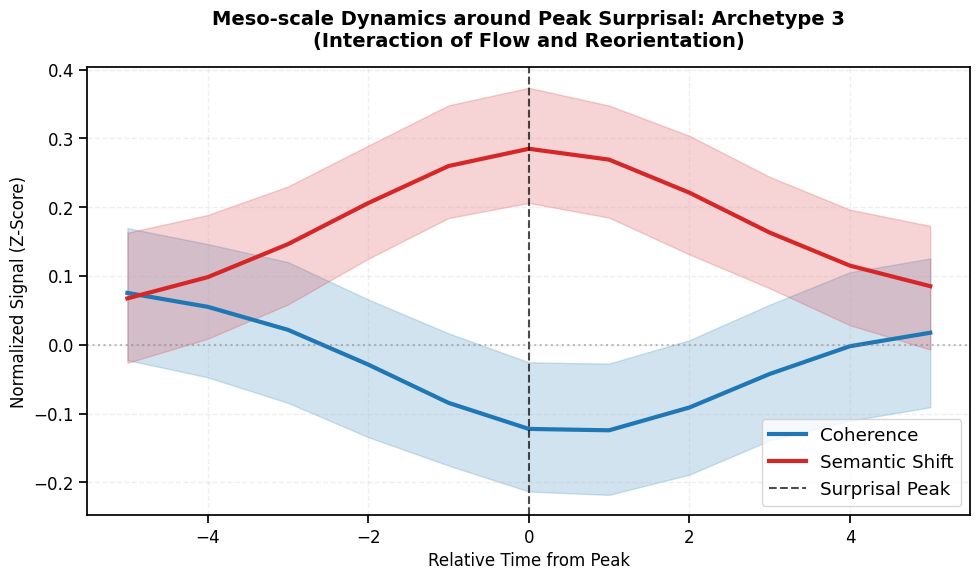

Successfully saved plot for Archetype 4 to: /Users/qgroup/Desktop/final_draft/figures/archetype_4_dynamics.png


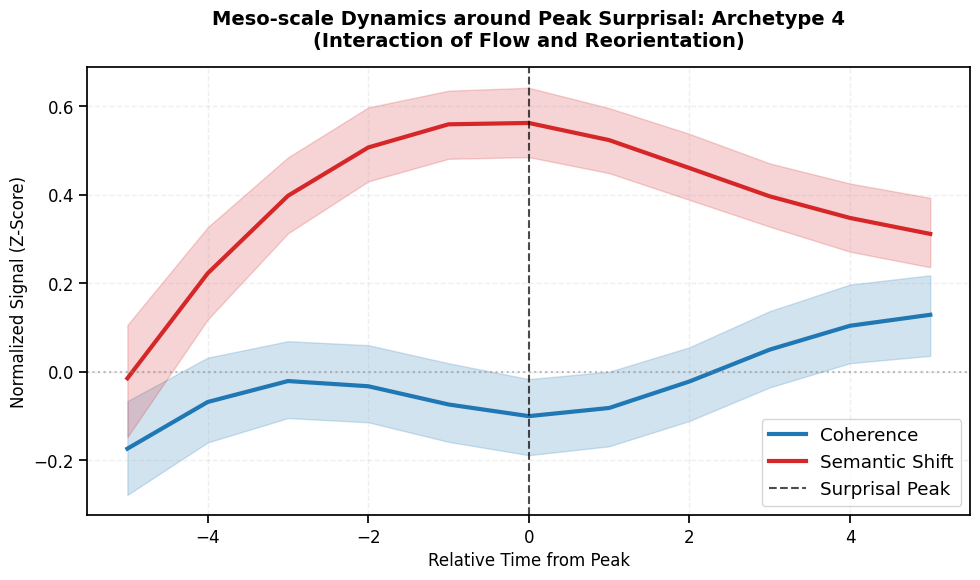

In [49]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 1. Configuration and Path Setup
# ==========================================
feat_file = f"{base_path}/short_novel_with_all_features_50.csv"
clust_file = f"{base_path}/short_novel_clustered_surprisal.csv"

output_folder=f"{base_path}/figures"

# Window size (±5 bins corresponds to ±10% of the narrative duration)
WINDOW_SIZE = 5

def safe_vec(x):
    """Safely converts string-formatted lists into Python list objects."""
    if isinstance(x, list): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return []
    return []

def main():
    print("Running Individual Windowed Comparison (Coherence vs Semantic Shift)...")
    
    if not os.path.exists(feat_file) or not os.path.exists(clust_file):
        print("Error: Required CSV files not found.")
        return

    # Load data
    df_feat = pd.read_csv(feat_file)
    df_clust = pd.read_csv(clust_file)

    # Signal columns
    sem_col = "semantic_shift_curve_50_smooth" 
    
    # Parse vectors
    df_feat["s_curve"] = df_feat["surprisal_curve_50_smooth"].apply(safe_vec)
    df_feat["c_curve"] = df_feat["coherence_curve_50_smooth"].apply(safe_vec)
    df_feat["m_curve"] = df_feat[sem_col].apply(safe_vec)
    
    # Filtering valid 50-bin narratives
    valid_mask = df_feat["s_curve"].map(len) == 50
    df_valid = df_feat[valid_mask].reset_index(drop=True)
    
    # Merge cluster labels
    min_len = min(len(df_valid), len(df_clust))
    df_valid = df_valid.iloc[:min_len].copy()
    df_clust = df_clust.iloc[:min_len]
    df_valid["cluster"] = df_clust["cluster_surprisal"].values

    unique_clusters = sorted(df_valid["cluster"].unique())

    # ==========================================
    # 2. Individual Plotting Loop
    # ==========================================
    for k in unique_clusters:
        sub_df = df_valid[df_valid["cluster"] == k]
        segments = []
        
        for _, row in sub_df.iterrows():
            s = np.array(row["s_curve"])
            c = np.array(row["c_curve"])
            m = np.array(row["m_curve"])
            
            # Individual Z-score normalization for cross-signal consistency
            if np.std(s) == 0 or np.std(c) == 0 or np.std(m) == 0: continue
            s_norm = (s - np.mean(s)) / np.std(s)
            c_norm = (c - np.mean(c)) / np.std(c)
            m_norm = (m - np.mean(m)) / np.std(m)
            
            # Robust Peak Detection (identifying the moment of surprise)
            search_start = 2
            s_search_area = s_norm[search_start:]
            if len(s_search_area) == 0: continue
            peak_idx = np.argmax(s_search_area) + search_start
            
            # Extract windows around the peak
            start = peak_idx - WINDOW_SIZE
            end = peak_idx + WINDOW_SIZE + 1
            if start < 0 or end > len(c_norm): continue
            
            c_seg = c_norm[start:end]
            m_seg = m_norm[start:end]
            x_axis = np.arange(-WINDOW_SIZE, WINDOW_SIZE + 1)
            
            # Data collection for long-format plotting
            for t, c_val, m_val in zip(x_axis, c_seg, m_seg):
                segments.append({"Time": t, "Type": "Coherence", "Value": c_val})
                segments.append({"Time": t, "Type": "Semantic Shift", "Value": m_val})
        
        # --- Create a separate figure for each cluster ---
        plt.figure(figsize=(10, 6))
        plot_data = pd.DataFrame(segments)
        
        # Plotting trajectories
        sns.lineplot(
            data=plot_data, x="Time", y="Value", hue="Type", 
            palette={"Coherence": "tab:blue", "Semantic Shift": "tab:red"},
            linewidth=3, errorbar=('ci', 95) # Include confidence interval for clarity
        )
        
        # Aesthetics and Labels
        plt.title(f"Meso-scale Dynamics around Peak Surprisal: Archetype {k}\n(Interaction of Flow and Reorientation)", 
                  fontsize=14, fontweight='bold', pad=15)
        plt.axvline(0, color='black', linestyle='--', alpha=0.7, label="Surprisal Peak")
        plt.axhline(0, color='gray', linestyle=':', alpha=0.5)
        
        plt.xlabel("Relative Time from Peak", fontsize=12)
        plt.ylabel("Normalized Signal (Z-Score)", fontsize=12)
        plt.legend(loc='lower right', fontsize='medium')
        plt.grid(True, alpha=0.2, linestyle='--')
        plt.tight_layout()
        
        # Save each plot individually
        out_path = f"{output_folder}/archetype_{k}_dynamics.png"
        plt.savefig(out_path, dpi=300, bbox_inches='tight')
        print(f"Successfully saved plot for Archetype {k} to: {out_path}")
        
        # Display the plot immediately
        plt.show()

if __name__ == "__main__":
    main()

Loading: /Users/qgroup/Desktop/final_draft/short_novel_with_all_curves_50.csv
Full dataset: 2921 stories
Filtered dataset (Excluding < 11 and > 186 sents): 2636 stories
Clustering with K=5...

=== Two-way Sensitivity Analysis Results ===
 Archetype  Correlation (r)   RMSE  Full_N  Filtered_N
         0           0.9691 0.1342     437         423
         1           0.9824 0.1340     641         553
         2           0.9967 0.0512     576         530
         3           0.9934 0.0854     801         743
         4           0.9510 0.1806     466         387

Saved visualization to: /Users/qgroup/Desktop/final_draft/figures/sensitivity_analysis_twoway.png


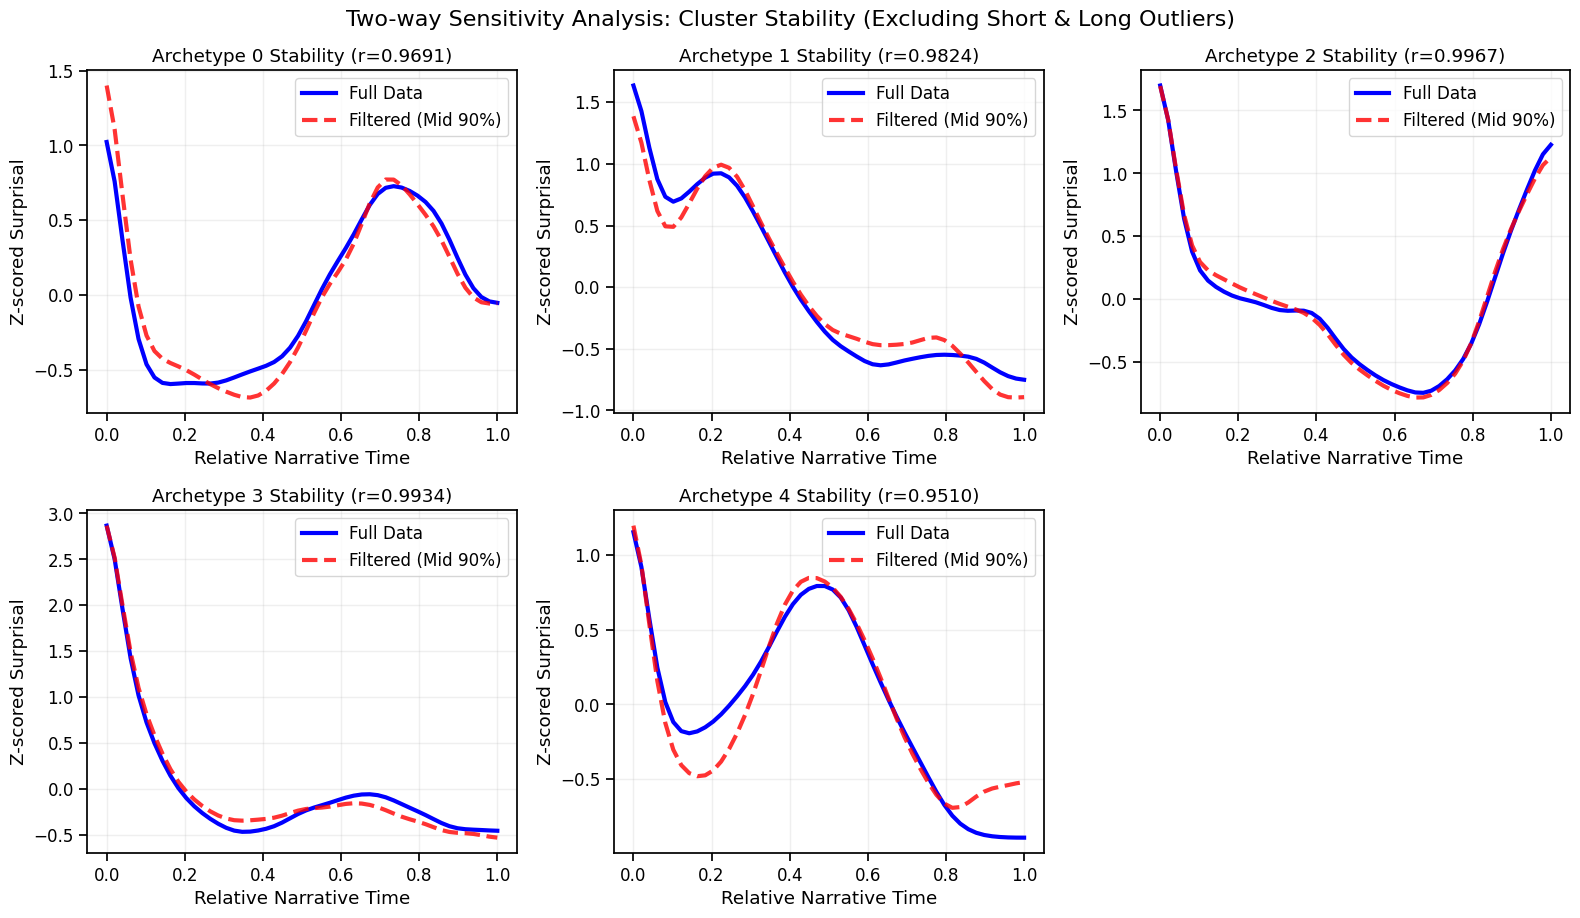

In [51]:
import os
import pandas as pd
import numpy as np
import ast
from sklearn.cluster import KMeans
from scipy.stats import zscore
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Configuration and Data Loading
# ==========================================
# Set the base_path according to your environment.
feat_file = f"{base_path}/short_novel_with_all_curves_50.csv"

print(f"Loading: {feat_file}")
df = pd.read_csv(feat_file)

def safe_vec(x):
    """
    Safely converts a string representation of a list into a Python list.
    """
    if isinstance(x, list): return x
    if not isinstance(x, str) or not x.strip(): return []
    try:
        v = ast.literal_eval(x)
        return list(v) if isinstance(v, (list, tuple)) else []
    except: return []

# Data cleaning: Use only data where the 50-dimensional curve is fully intact
df["surp_curve"] = df["surprisal_curve_50_smooth"].apply(safe_vec)
df = df[df["surp_curve"].map(len) == 50].reset_index(drop=True)

# If sentence count information is missing, generate it based on surprisal_list length
if 'surp_len_sents' not in df.columns:
    df['surp_len_sents'] = df['surprisal_list'].apply(lambda x: len(safe_vec(x)))

# ==========================================
# 2. Dataset Partitioning for Two-way Sensitivity Analysis
# ==========================================
# Calculate upper/lower 5% thresholds (Filter for middle 90% of data)
lower_threshold = df['surp_len_sents'].quantile(0.05)
upper_threshold = df['surp_len_sents'].quantile(0.95)

df_filtered = df[
    (df['surp_len_sents'] >= lower_threshold) & 
    (df['surp_len_sents'] <= upper_threshold)
].copy()

print(f"Full dataset: {len(df)} stories")
print(f"Filtered dataset (Excluding < {lower_threshold:.0f} and > {upper_threshold:.0f} sents): {len(df_filtered)} stories")

def get_scaled_matrix(target_df):
    """
    Converts list data to a matrix and performs row-wise (story-level) Z-score normalization.
    """
    X = np.vstack(target_df["surp_curve"].values)
    X_scaled = zscore(X, axis=1)
    return np.nan_to_num(X_scaled)

X_full = get_scaled_matrix(df)
X_filt = get_scaled_matrix(df_filtered)

# ==========================================
# 3. Perform Clustering Separately (K=5)
# ==========================================
K = 5
print(f"Clustering with K={K}...")
km_full = KMeans(n_clusters=K, random_state=42, n_init=20).fit(X_full)
km_filt = KMeans(n_clusters=K, random_state=42, n_init=20).fit(X_filt)

centroids_full = km_full.cluster_centers_
centroids_filt = km_filt.cluster_centers_

# ==========================================
# 4. Cluster Matching (Based on Shape Similarity)
# ==========================================
# Matching filtered data centroids to the most similar full data centroids
dist_matrix = cdist(centroids_filt, centroids_full, metric='euclidean')
matched_indices = dist_matrix.argmin(axis=1) 

# ==========================================
# 5. Visualization and Statistics Calculation
# ==========================================
plt.figure(figsize=(16, 9))
x_axis = np.linspace(0, 1, 50)
stability_records = []

for i, full_idx in enumerate(matched_indices):
    c_full = centroids_full[full_idx]
    c_filt = centroids_filt[i]
    
    # Calculate metrics: Pearson Correlation and RMSE
    corr, _ = pearsonr(c_full, c_filt)
    rmse = np.sqrt(mean_squared_error(c_full, c_filt))
    
    # Log statistics
    stability_records.append({
        "Archetype": i,
        "Correlation (r)": round(corr, 4),
        "RMSE": round(rmse, 4),
        "Full_N": len(km_full.labels_[km_full.labels_ == full_idx]),
        "Filtered_N": len(km_filt.labels_[km_filt.labels_ == i])
    })

    # Generate subplots for comparison
    plt.subplot(2, 3, i+1)
    plt.plot(x_axis, c_full, 'b-', linewidth=3, label='Full Data')
    plt.plot(x_axis, c_filt, 'r--', linewidth=3, alpha=0.8, label='Filtered (Mid 90%)')
    plt.title(f"Archetype {i} Stability (r={corr:.4f})")
    plt.xlabel("Relative Narrative Time")
    plt.ylabel("Z-scored Surprisal")
    plt.legend()
    plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.suptitle("Two-way Sensitivity Analysis: Cluster Stability (Excluding Short & Long Outliers)", y=1.02, fontsize=16)

# Save the visualization and statistical results
plt.savefig(f"{base_path}/figures/sensitivity_analysis_twoway.png")
stability_df = pd.DataFrame(stability_records)
stability_df.to_csv(f"{base_path}/sensitivity_stats_twoway.csv", index=False)

print("\n=== Two-way Sensitivity Analysis Results ===")
print(stability_df.to_string(index=False))
print(f"\nSaved visualization to: {base_path}/figures/sensitivity_analysis_twoway.png")